In [1]:
import matplotlib.pyplot as plt
import numpy as np
from reservoirpy.observables import nrmse, rsquare
from reservoirpy.nodes import Ridge, NVAR
from pandas import read_csv
%matplotlib inline

## Read Data from .csv

In [2]:
data_time = read_csv('../Dataset/Lorenz_data.csv', usecols=[0])
time = data_time.values
time = time.astype('float32')

data_Lorenz = read_csv('../Dataset/Lorenz_data.csv', usecols=[1, 2, 3])
data_Lorenz = data_Lorenz.values
data_Lorenz = data_Lorenz.astype('float32')

data_Rossler = read_csv('../Dataset/Rossler_data.csv', usecols=[1, 2, 3])
data_Rossler = data_Rossler.values
data_Rossler = data_Rossler.astype('float32')

data_Chen = read_csv('../Dataset/Chen_data.csv', usecols=[1, 2, 3])
data_Chen = data_Chen.values
data_Chen = data_Chen.astype('float32')

data_Qi = read_csv('../Dataset/Qi_data.csv', usecols=[1, 2, 3])
data_Qi = data_Qi.values
data_Qi = data_Qi.astype('float32')

# data_noise_Lorenz = read_csv('../Dataset/noise_Lorenz_data.csv', usecols=[1, 2, 3])
# data_noise_Lorenz = data_noise_Lorenz.values
# data_noise_Lorenz = data_noise_Lorenz.astype('float32')

data_Chua = read_csv('../Dataset/Chua_data.csv', usecols=[1, 2, 3])
data_Chua = data_Chua.values
data_Chua = data_Chua.astype('float32')

In [3]:
# X = data_noise_Lorenz  ## Change data input here
X = data_Chua
# X = 2 * (X - X.min()) / (X.max() - X.min()) - 1
total_steps = len(X)
warm_steps = round(0.10*total_steps)
train_steps = round(0.20*total_steps)
test_steps = round(0.70*total_steps)

## Train NGRC Model
$O_{lin,i}=X_i \oplus X_{i-s} \oplus X_{i-2s} \oplus \cdots \oplus X_{i-(k-1)s}$ \
Where $k$ denotes delay, $s-1$ denotes the number of skipped steps between consecutive observations.

In [4]:
nvar = NVAR(delay=2, order=2, strides=1)
readout = Ridge(3, ridge=2.5e-6)

model = nvar >> readout
model

'Model-0': Model('NVAR-0', 'Ridge-0')

In [5]:
pred_steps = 1
# Xi  = X[:train_steps+warm_steps-1]
# dXi = X[1:train_steps+warm_steps] - X[:train_steps+warm_steps-1]

Xi  = X[:train_steps+warm_steps-pred_steps]
dXi = X[pred_steps:train_steps+warm_steps] - X[:train_steps+warm_steps-pred_steps]

model = model.fit(Xi, dXi, warmup=warm_steps)

Running Model-0: 1499it [00:00, 6125.47it/s]<?, ?it/s]
Running Model-0: 100%|██████████| 1/1 [00:00<00:00,  3.58it/s]


Fitting node Ridge-0...


In [6]:
nvar.run(X[warm_steps+train_steps-2:warm_steps+train_steps])
u = X[warm_steps+train_steps]
res = np.zeros((test_steps, readout.output_dim))
for i in range(test_steps):
    u = u + model(u)
    res[i, :] = u

Running NVAR-0: 100%|██████████| 2/2 [00:00<?, ?it/s]


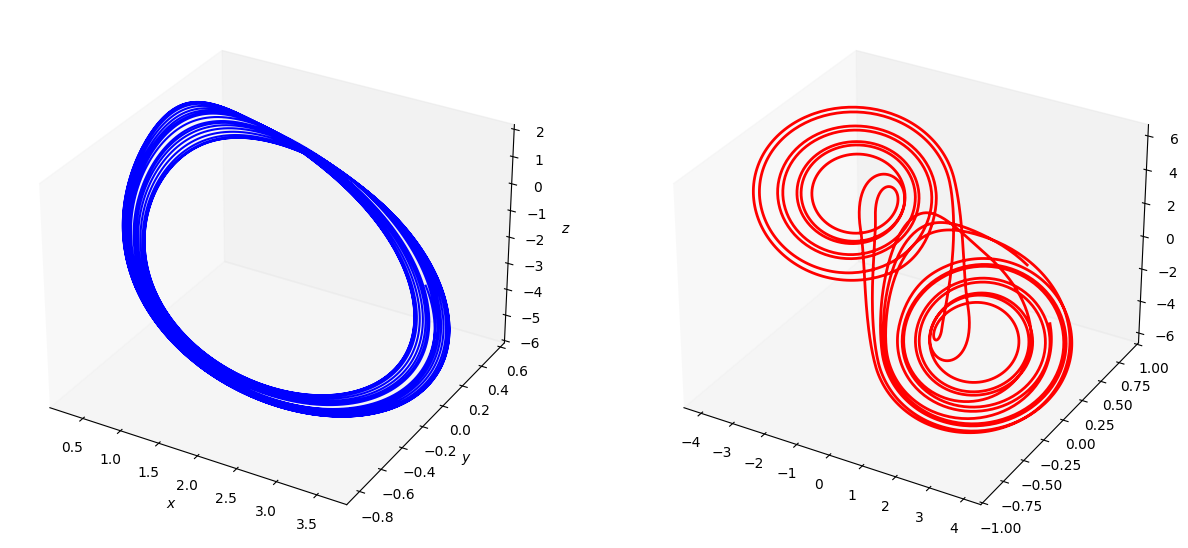

In [7]:
N = test_steps
Y = X[warm_steps+train_steps:]

fig = plt.figure(figsize=(15, 10))
ax  = fig.add_subplot(121, projection='3d')
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.grid(False)
ax.plot(res[:, 0], res[:, 1], res[:, 2], color='b')

ax2 = fig.add_subplot(122, projection='3d')
ax2.grid(False)
ax2.plot(Y[:, 0], Y[:, 1], Y[:, 2], color='r', lw=2.0)

In [ ]:
T = time[warm_steps+train_steps:]

fig = plt.figure(figsize=(10, 6))
ax  = fig.add_subplot(311)
ax.set_ylabel("$x$")
ax.grid(False)
ax.plot(T, res[:, 0], color='b')
ax.plot(T, Y[:, 0], color='r')

ax2 = fig.add_subplot(312)
ax2.set_ylabel("$y$")
ax2.grid(False)
ax2.plot(T, res[:, 1], color='b')
ax2.plot(T, Y[:, 1], color='r')

ax3 = fig.add_subplot(313)
ax3.set_xlabel("$time$")
ax3.set_ylabel("$z$")
ax3.grid(False)
ax3.plot(T, res[:, 2], color='b')
ax3.plot(T, Y[:, 2], color='r')


## Calculate Error

r^2=0.3009108049945496, nrmse=0.16360195170820102


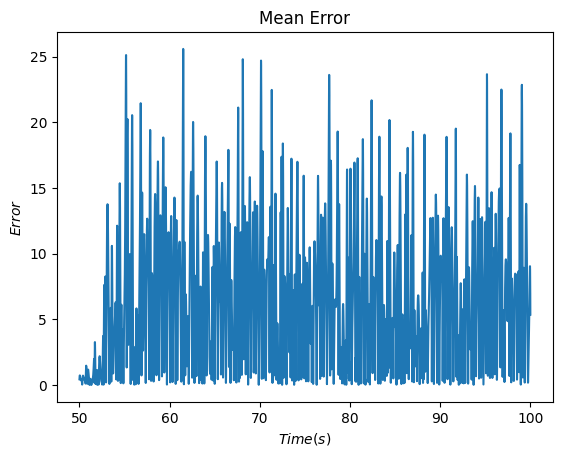

In [ ]:
print(f'r^2={rsquare(Y, res)}, nrmse={nrmse(Y, res)}')
error = res - Y
e = np.abs(np.mean(error, axis=1))
T = time[warm_steps+train_steps:]

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(T, e)
ax.set_title("Mean Error")
ax.set_xlabel("$Time(s)$")
ax.set_ylabel("$Error$")
ax.grid(False)

## Plot output weight

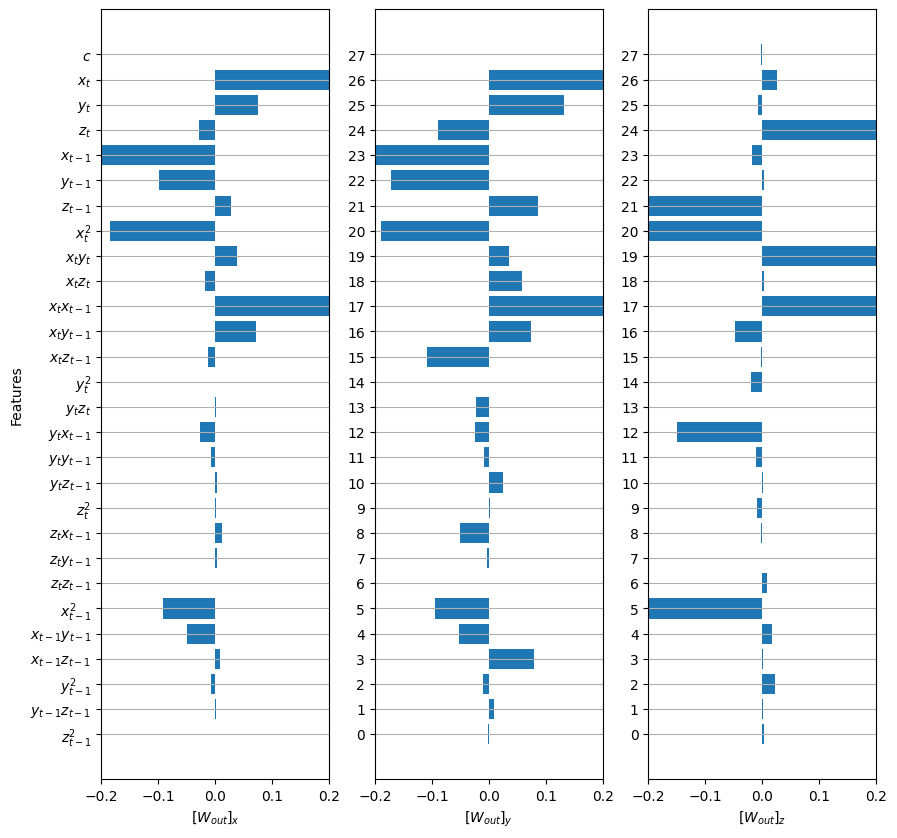

In [ ]:
lin = ["$x_t$", "$y_t$", "$z_t$", "$x_{t-1}$", "$y_{t-1}$", "$z_{t-1}$"]

nonlin = []
for idx in nvar._monomial_idx:
    idx = idx.astype(int)
    if idx[0] == idx[1]:
        c = lin[idx[0]][:-1] + "^2$"
    else:
        c = " ".join((lin[idx[0]][:-1], lin[idx[1]][1:]))

    nonlin.append(c)

coefs = ["$c$"] + lin + nonlin

fig = plt.figure(figsize=(10, 10))

Wout = np.r_[readout.bias, readout.Wout]
x_Wout, y_Wout, z_Wout = Wout[:, 0], Wout[:, 1], Wout[:, 2]

ax = fig.add_subplot(131)
ax.set_xlim(-0.2, 0.2)
ax.grid(axis="y")
ax.set_xlabel("$[W_{out}]_x$")
ax.set_ylabel("Features")
ax.set_yticks(np.arange(len(coefs)))
ax.set_yticklabels(coefs[::-1])
ax.barh(np.arange(x_Wout.size), x_Wout.ravel()[::-1])

ax1 = fig.add_subplot(132)
ax1.set_xlim(-0.2, 0.2)
ax1.grid(axis="y")
ax1.set_yticks(np.arange(len(coefs)))
ax1.set_xlabel("$[W_{out}]_y$")
ax1.barh(np.arange(y_Wout.size), y_Wout.ravel()[::-1])

ax2 = fig.add_subplot(133)
ax2.set_xlim(-0.2, 0.2)
ax2.grid(axis="y")
ax2.set_yticks(np.arange(len(coefs)))
ax2.set_xlabel("$[W_{out}]_z$")
ax2.barh(np.arange(z_Wout.size), z_Wout.ravel()[::-1])

plt.show()